In [1]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [5]:
!unzip -o "/content/Dataset.zip"

Archive:  /content/Dataset.zip
  inflating: Dataset/data.yaml       
  inflating: Dataset/images/test/0bd32331-a8_1.jpg  
  inflating: Dataset/images/test/12d44150-test-6.jpg  
  inflating: Dataset/images/test/5ba58e1c-test_2.jpg  
  inflating: Dataset/images/test/7d2277cc-a5_2.jpg  
  inflating: Dataset/images/test/9-2.jpg  
  inflating: Dataset/images/test/9351e6f7-test-9.jpg  
  inflating: Dataset/images/test/98e6eacf-test_3.jpg  
  inflating: Dataset/images/test/ea13a9ad-a5_1.jpg  
  inflating: Dataset/images/train/0ef2a272-train-1.jpg  
  inflating: Dataset/images/train/1472703c-a1_3.jpg  
  inflating: Dataset/images/train/14d55191-a2_2.jpg  
  inflating: Dataset/images/train/2f35f9cd-a2_1.jpg  
  inflating: Dataset/images/train/33eb01b2-a3_4.jpg  
  inflating: Dataset/images/train/380b585a-a3_1.jpg  
  inflating: Dataset/images/train/4091c858-a1_1.jpg  
  inflating: Dataset/images/train/4c2d7d5d-a3_2.jpg  
  inflating: Dataset/images/train/752e3095-a3_3.jpg  
  inflating: Dataset

In [6]:
# Chia dataset thành các thư mục train/val/test
import os
import shutil
import random

root = "/content/Dataset"

# Đường dẫn ảnh và nhãn
img_dir = os.path.join(root, "images")
lbl_dir = os.path.join(root, "labels")

splits = ["train", "val", "test"]
for s in splits:
    os.makedirs(os.path.join(img_dir, s), exist_ok=True)
    os.makedirs(os.path.join(lbl_dir, s), exist_ok=True)

# Tỉ lệ
train_r, val_r = 0.7, 0.3  # 70% train, 20% val, 10% test

# Danh sách ảnh
images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)

n = len(images)
train_f = images[:int(n*train_r)]
val_f   = images[int(n*train_r):int(n*(train_r+val_r))]
test_f  = images[int(n*(train_r+val_r)):]

# Hàm di chuyển ảnh + nhãn theo từng tập
def move(files, split):
    for f in files:
        shutil.move(os.path.join(img_dir, f), os.path.join(img_dir, split, f))
        lbl = f.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(os.path.join(lbl_dir, lbl)):
            shutil.move(os.path.join(lbl_dir, lbl), os.path.join(lbl_dir, split, lbl))

move(train_f, "train")
move(val_f, "val")
move(test_f, "test")

print("Dataset OK!")

Dataset OK!


In [20]:
from ultralytics import YOLO
import torch
import yaml

torch.cuda.empty_cache()
yaml_path = "/content/Dataset/data.yaml"

# ============================================================
# FIXING data.yaml PATHS
# ============================================================
# Read the existing data.yaml file
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update the 'train', 'val', and 'test' paths to be absolute paths for Colab
data_config['train'] = '/content/Dataset/images/train'
data_config['val'] = '/content/Dataset/images/val'
data_config['test'] = '/content/Dataset/images/test'

# Save the updated data.yaml back to the file
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"Updated {yaml_path} with correct image paths.")

# ============================================================
# TRAINING
# ============================================================
model = YOLO("yolov8n.pt")

results = model.train(
data=yaml_path,
epochs=300,
imgsz=960,
batch=4,
device="",

# Training params
patience=300,
optimizer='AdamW',
lr0=0.01,
close_mosaic=10,
amp=True,
cache=True,
)

Updated /content/Dataset/data.yaml with correct image paths.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optim

In [ ]:
# Load mô hình tốt nhất và in chỉ số đánh giá
best_model = YOLO(results.save_dir / "weights" / "best.pt")
metrics = best_model.val(
    data=yaml_path,
    imgsz=960,
    batch=4,
    save_txt=True,
    save_conf=True,
    save=True,
    plots=True
    )
# In kết quả chính
print(f"\nmAP50 = {metrics.box.map50:.3f}")
print(f"mAP50-95 = {metrics.box.map:.3f}")
print(f"Precision = {metrics.box.mp:.3f}")      # đúng trên những gì dự đoán
print(f"Recall = {metrics.box.mr:.3f}")         # mô hình tìm được

# Tính F1-score từ Precision và Recall
precision = metrics.box.mp
recall = metrics.box.mr

f1_score = 2 * precision * recall / (precision + recall + 1e-16)

print(f"F1-score = {f1_score:.3f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2439.2±535.5 MB/s, size: 235.7 KB)
val: Scanning /content/Dataset/labels/val.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 3.1Mit/s 0.0s
val: /content/Dataset/images/val/131ca020-a4_1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1s/it 6.3s
                   all         11       1965      0.866      0.878      0.851      0.605
                   bad          9        626      0.976      0.914      0.946      0.689
                  good          3        450      0.774      0.849      0.799      0.494
             shell egg          5        889      0.847      0.872      0.808      0.633
Speed: 16.3ms preprocess, 11.5ms inference, 0.0ms loss, 50.8ms pos

In [24]:
# Kiểm tra phân bố lớp trong dataset (0/1)
import os
from collections import Counter

def count_classes_simple(label_folder):
    counter = Counter()

    for txt in os.listdir(label_folder):
        if not txt.endswith(".txt"):
            continue

        path = os.path.join(label_folder, txt)

        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if line:  # Bỏ qua dòng trống
                    cls = int(line.split()[0])
                    counter[cls] += 1

    return counter


root = "/content/Dataset/labels"

train_counter = count_classes_simple(os.path.join(root, "train"))
val_counter   = count_classes_simple(os.path.join(root, "val"))
test_counter  = count_classes_simple(os.path.join(root, "test"))

print("==== DATASET STATISTIC ====")
print(f"TRAIN: {dict(train_counter)}")
print(f"VAL:   {dict(val_counter)}")
print(f"TEST:  {dict(test_counter)}")
print()

==== DATASET STATISTIC ====
TRAIN: {0: 870, 2: 2089, 1: 1483}
VAL:   {0: 626, 2: 891, 1: 450}
TEST:  {0: 142, 2: 1267}



In [25]:
# Kiểm tra tổng số đối tượng trong tập train và tỉ lệ từng lớp
import os

train_dir = "/content/Dataset/images/train"
label_dir = "/content/Dataset/labels/train"

imgs = os.listdir(train_dir)
labels = os.listdir(label_dir)

print("Ảnh train:", len(imgs))
print("Label train:", len(labels))

# Kiểm tra số GOOD, BAD và Shell egg ĐÚNG
bad = 0   # Class 0
good = 0  # Class 1
shell = 0  # Class 2

for lbl in labels:
    with open(os.path.join(label_dir, lbl), 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls = int(line.split()[0])
            if cls == 0:
                bad += 1   # ← Class 0 = BAD
            elif cls == 1:
                good += 1  # ← Class 1 = GOOD
            elif cls == 2:
                shell += 1  # ← Class 2 = SHELL


print(f"BAD (class 0):  {bad}")
print(f"GOOD (class 1): {good}")
print(f"SHELL (class 2): {shell}")
print(f"Total: {bad + good + shell}")
print(f"Ratio BAD: {bad/(bad+good+shell)*100:.1f}%")
print(f"Ratio GOOD: {good/(bad+good+shell)*100:.1f}%")
print(f"Ratio SHELL: {shell/(bad+good+shell)*100:.1f}%")

Ảnh train: 19
Label train: 19
BAD (class 0):  870
GOOD (class 1): 1483
SHELL (class 2): 2089
Total: 4442
Ratio BAD: 19.6%
Ratio GOOD: 33.4%
Ratio SHELL: 47.0%


In [30]:
# Chạy mô hình trên ảnh test và xuất kết quả dự đoán (.txt) vào thư mục labels/test
from ultralytics import YOLO

import os
import glob
import shutil

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# Thư mục ảnh test
folder_path = "/content/Dataset/images/test/*"

# Nơi muốn lưu file txt
save_label_dir = "/content/Dataset/labels/test"

# Lấy danh sách ảnh
image_list = glob.glob(folder_path)

for img_path in image_list:
    results = model.predict(
        source=img_path,
        conf=0.4,
        iou=0.5,
        max_det=9999,
        save=True,
        save_txt=True,
        show_labels=False,
        show_conf=False
    )

    r = results[0]
    boxes = r.boxes
    base = os.path.splitext(os.path.basename(img_path))[0]

    print("\n" + "="*60)
    print(f"Ảnh: {os.path.basename(img_path)}")

    # Nếu không phát hiện trứng
    if len(boxes) == 0:
        print(" KHÔNG phát hiện trứng nào!")
        continue

    # Đếm
    total = len(boxes)
    bad  = sum(1 for b in boxes if int(b.cls[0]) == 0)
    good = sum(1 for b in boxes if int(b.cls[0]) == 1)
    shell = sum(1 for b in boxes if int(b.cls[0]) == 2)

    print(f" Tổng phát hiện: {total}")
    print(f" BAD : {bad}")
    print(f" GOOD: {good}")
    print(f" SHELL : {shell}")

    # Copy TXT vào thư mục test labels
    predict_label_dir = os.path.join(r.save_dir, "labels")
    src = os.path.join(predict_label_dir, base + ".txt")
    dst = os.path.join(save_label_dir, base + ".txt")

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f" File TXT đã lưu vào: {dst} (ghi đè nếu có)")
    else:
        print(" Không tìm thấy file .txt trong predict, có thể YOLO không tạo txt!")

print("\n HOÀN TẤT! Toàn bộ ảnh đã xử lý xong.")



image 1/1 /content/Dataset/images/test/98e6eacf-test_3.jpg: 800x960 112 goods, 12.3ms
Speed: 5.3ms preprocess, 12.3ms inference, 2.0ms postprocess per image at shape (1, 3, 800, 960)
Results saved to /content/runs/detect/predict-10
1 label saved to /content/runs/detect/predict-10/labels

Ảnh: 98e6eacf-test_3.jpg
 Tổng phát hiện: 112
 BAD : 0
 GOOD: 112
 SHELL : 0
 File TXT đã lưu vào: /content/Dataset/labels/test/98e6eacf-test_3.txt (ghi đè nếu có)

image 1/1 /content/Dataset/images/test/9-2.jpg: 960x704 138 bads, 1 good, 11.8ms
Speed: 6.9ms preprocess, 11.8ms inference, 2.1ms postprocess per image at shape (1, 3, 960, 704)
Results saved to /content/runs/detect/predict-10
2 labels saved to /content/runs/detect/predict-10/labels

Ảnh: 9-2.jpg
 Tổng phát hiện: 139
 BAD : 138
 GOOD: 1
 SHELL : 0
 File TXT đã lưu vào: /content/Dataset/labels/test/9-2.txt (ghi đè nếu có)

image 1/1 /content/Dataset/images/test/7d2277cc-a5_2.jpg: 960x928 5 bads, 278 shell eggs, 12.7ms
Speed: 7.5ms preproces

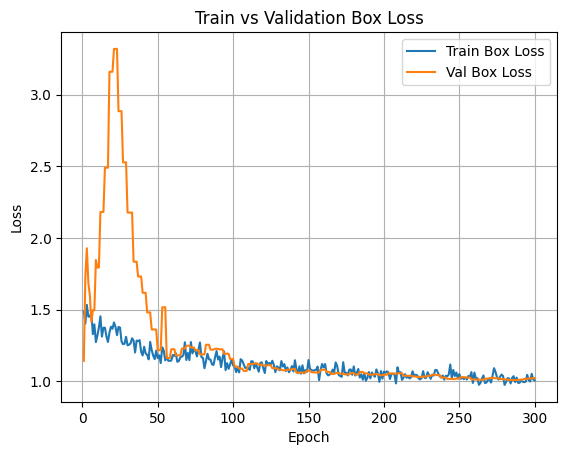

In [33]:
# Vẽ quá trình train (Loss, Precision, Recall)
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/runs/detect/train-2/results.csv")

plt.figure()
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Box Loss")
plt.grid(True)
plt.show()

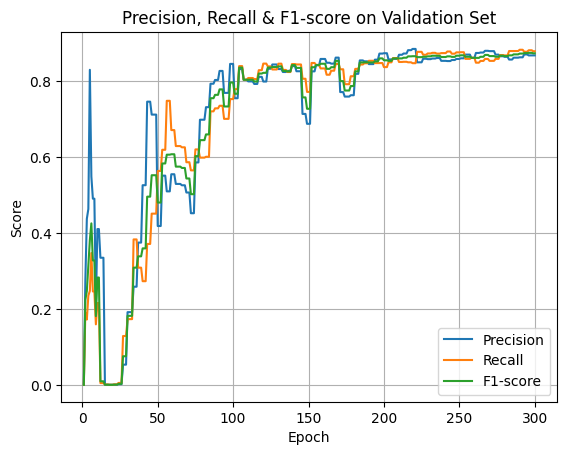

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/runs/detect/train-2/results.csv")

# Lấy Precision và Recall
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

# Tính F1-score
f1_score = 2 * precision * recall / (precision + recall + 1e-16)

plt.figure()
plt.plot(df['epoch'], precision, label='Precision')
plt.plot(df['epoch'], recall, label='Recall')
plt.plot(df['epoch'], f1_score, label='F1-score')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Precision, Recall & F1-score on Validation Set")
plt.grid(True)
plt.show()

In [35]:
from ultralytics import YOLO
from pathlib import Path

runs_dir = Path("/content/runs/detect")

best_models = []

for run in runs_dir.glob("train*"):
    weight = run / "weights" / "best.pt"
    if weight.exists():
        best_models.append(weight)

print("Found best models:")
for w in best_models:
    print(w)

Found best models:
/content/runs/detect/train/weights/best.pt
/content/runs/detect/train-2/weights/best.pt


In [36]:
from ultralytics import YOLO
from pathlib import Path

yaml_path = "/content/Dataset/data.yaml"

runs_dir = Path("/content/runs/detect")

best_models = []

for run in runs_dir.glob("train*"):
    weight = run / "weights" / "best.pt"
    if weight.exists():
        best_models.append(weight)

for w in best_models:
    model = YOLO(w)
    metrics = model.val(
        data=yaml_path,
        imgsz=960,
        batch=4
    )
    print(w, metrics.box.map50, metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2167.1±589.8 MB/s, size: 140.3 KB)
val: Scanning /content/Dataset/labels/val.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 3.8Mit/s 0.0s
val: /content/Dataset/images/val/131ca020-a4_1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.9s
                   all         11       1965      0.221      0.403      0.225      0.163
                   bad          9        626      0.337      0.337      0.118     0.0854
                  good          3        450          0          0          0          0
             shell egg          5        889      0.325      0.873      0.556      0.403
Speed: 22.7ms preprocess, 17.4ms inference, 0.0ms loss, 43.9ms pos

Saving test 3.jpg to test 3 (3).jpg

image 1/1 /content/test 3 (3).jpg: 960x960 22 bads, 3 goods, 720 shell eggs, 12.0ms
Speed: 6.4ms preprocess, 12.0ms inference, 3.4ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /content/runs/detect/predict-27

================ KẾT QUẢ NHẬN DIỆN ================
Tổng số trứng phát hiện: 745

Số lượng và phần trăm từng lớp:
BAD: 22 quả - 2.95%
GOOD: 3 quả - 0.40%
SHELL: 720 quả - 96.64%


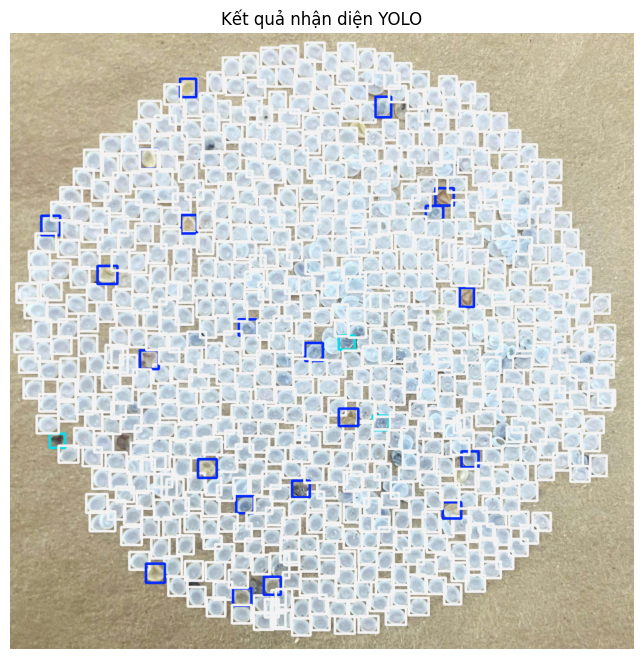

In [55]:
# ===================== NHẬN DIỆN ẢNH BÊN NGOÀI + TÍNH PHẦN TRĂM TỪNG LỚP =====================

from ultralytics import YOLO
from google.colab import files
from collections import Counter
import matplotlib.pyplot as plt
import cv2

# Load model đã train
# Sửa lại đường dẫn best.pt cho đúng với notebook của bạn
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# Thứ tự lớp của bạn: bad, good, shell
class_names = {
    0: "BAD",
    1: "GOOD",
    2: "SHELL"
}

# Upload ảnh từ máy tính lên Colab
uploaded = files.upload()

# Lấy tên ảnh vừa upload
image_path = list(uploaded.keys())[0]

# Dự đoán ảnh
results = model.predict(
    source=image_path,
    imgsz=960,
    conf=0.35,
    iou=0.45,
    max_det=2000,
    save=True
)

# Lấy kết quả ảnh đầu tiên
result = results[0]

# Đếm số lượng từng lớp
counts = Counter()

if result.boxes is not None and len(result.boxes) > 0:
    class_ids = result.boxes.cls.cpu().numpy().astype(int)

    for class_id in class_ids:
        counts[class_id] += 1

# Tổng số đối tượng phát hiện
total = sum(counts.values())

print("\n================ KẾT QUẢ NHẬN DIỆN ================")
print(f"Tổng số trứng phát hiện: {total}")

print("\nSố lượng và phần trăm từng lớp:")

if total == 0:
    print("Không phát hiện được đối tượng nào.")
else:
    for class_id in sorted(class_names.keys()):
        count = counts.get(class_id, 0)
        percent = count / total * 100
        print(f"{class_names[class_id]}: {count} quả - {percent:.2f}%")

# Hiển thị ảnh đã vẽ bounding box
img_result = result.plot(
    labels=False,
    conf= False,
    boxes=True
)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Kết quả nhận diện YOLO")
plt.show()